## 1. Import thư viện

In [19]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", palette="tab10")

## 2. Đọc dữ liệu từ file zip

File `archive.zip` nằm cùng thư mục với notebook này. Nếu chạy notebook từ repo root, cell dưới cũng tự tìm theo đường dẫn `assginment_week_11/RNN/archive.zip`.

In [20]:
zip_candidates = [
    Path("archive.zip"),
    Path("assginment_week_11/RNN/archive.zip"),
]

ZIP_PATH = next((path for path in zip_candidates if path.exists()), None)
if ZIP_PATH is None:
    raise FileNotFoundError("Không tìm thấy archive.zip. Hãy chạy notebook từ folder RNN hoặc repo root.")

with zipfile.ZipFile(ZIP_PATH) as zf:
    zip_files = zf.namelist()

zip_files

['btcusd_1-min_data.csv']

In [21]:
csv_name = [name for name in zip_files if name.lower().endswith(".csv")][0]

dtype_map = {
    "Timestamp": "float64",
    "Open": "float32",
    "High": "float32",
    "Low": "float32",
    "Close": "float32",
    "Volume": "float32",
}

with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open(csv_name) as file:
        df = pd.read_csv(file, dtype=dtype_map)

df.head()

,Timestamp,Open,High,Low,Close,Volume
0,"1,325,412,060.000000",4.580000,4.580000,4.580000,4.580000,0.000000
1,"1,325,412,120.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2,"1,325,412,180.000000",4.580000,4.580000,4.580000,4.580000,0.000000
3,"1,325,412,240.000000",4.580000,4.580000,4.580000,4.580000,0.000000
4,"1,325,412,300.000000",4.580000,4.580000,4.580000,4.580000,0.000000


## 3. Tổng quan dữ liệu

Dữ liệu có các cột OHLCV:

- `Open`: giá mở cửa của mỗi mốc thời gian.
- `High`: giá cao nhất trong mốc đó.
- `Low`: giá thấp nhất trong mốc đó.
- `Close`: giá đóng cửa, thường được chọn làm target dự báo.
- `Volume`: khối lượng giao dịch.
- `Timestamp`: thời gian Unix, cần chuyển thành datetime để phân tích chuỗi thời gian.

In [22]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())
display(df.info(memory_usage="deep"))

Shape: (7559696, 6)


,Timestamp,Open,High,Low,Close,Volume
0,"1,325,412,060.000000",4.580000,4.580000,4.580000,4.580000,0.000000
1,"1,325,412,120.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2,"1,325,412,180.000000",4.580000,4.580000,4.580000,4.580000,0.000000
3,"1,325,412,240.000000",4.580000,4.580000,4.580000,4.580000,0.000000
4,"1,325,412,300.000000",4.580000,4.580000,4.580000,4.580000,0.000000


,Timestamp,Open,High,Low,Close,Volume
7559691,"1,779,063,120.000000","77,036.000000","77,041.000000","76,983.000000","77,003.000000",2.991790
7559692,"1,779,063,180.000000","76,999.000000","77,042.000000","76,950.000000","77,042.000000",0.966602
7559693,"1,779,063,240.000000","77,047.000000","77,150.000000","77,047.000000","77,150.000000",0.725973
7559694,"1,779,063,300.000000","77,169.000000","77,185.000000","77,110.000000","77,180.000000",1.248170
7559695,"1,779,063,360.000000","77,180.000000","77,282.000000","77,180.000000","77,270.000000",0.529360


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559696 entries, 0 to 7559695
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float32
 2   High       float32
 3   Low        float32
 4   Close      float32
 5   Volume     float32
dtypes: float32(5), float64(1)
memory usage: 201.9 MB


None

In [23]:
df["datetime"] = pd.to_datetime(df["Timestamp"], unit="s", utc=True)
df = df.sort_values("datetime").set_index("datetime")

print("Từ ngày:", df.index.min())
print("Đến ngày:", df.index.max())
print("Số dòng:", len(df))
display(df.head())

Từ ngày: 2012-01-01 10:01:00+00:00
Đến ngày: 2026-05-18 00:16:00+00:00
Số dòng: 7559696


,Timestamp,Open,High,Low,Close,Volume
datetime,,,,,,
2012-01-01 10:01:00+00:00,"1,325,412,060.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2012-01-01 10:02:00+00:00,"1,325,412,120.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2012-01-01 10:03:00+00:00,"1,325,412,180.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2012-01-01 10:04:00+00:00,"1,325,412,240.000000",4.580000,4.580000,4.580000,4.580000,0.000000
2012-01-01 10:05:00+00:00,"1,325,412,300.000000",4.580000,4.580000,4.580000,4.580000,0.000000


## 4. Kiểm tra chất lượng dữ liệu

In [24]:
quality_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "unique_count": df.nunique(),
    "dtype": df.dtypes.astype(str),
})

display(quality_summary)

,missing_count,missing_rate,unique_count,dtype
Timestamp,0,0.000000,7559696,float64
Open,0,0.000000,1748176,float32
High,0,0.000000,1712691,float32
Low,0,0.000000,1724001,float32
Close,0,0.000000,1739842,float32
Volume,0,0.000000,5324952,float32


In [25]:
duplicate_timestamp_count = df.index.duplicated().sum()
zero_volume_count = (df["Volume"] == 0).sum()
negative_price_count = (df[["Open", "High", "Low", "Close"]] <= 0).sum()

print("Duplicate timestamp:", duplicate_timestamp_count)
print("Zero volume rows:", zero_volume_count, f"({zero_volume_count / len(df):.2%})")
print("Non-positive prices:")
display(negative_price_count)

Duplicate timestamp: 0
Zero volume rows: 1311936 (17.35%)
Non-positive prices:


Open     0
High     0
Low      0
Close    0
dtype: int64

In [26]:
time_delta = df.index.to_series().diff().dropna()

print("Các khoảng cách thời gian phổ biến nhất:")
display(time_delta.value_counts().head(10))

gap_rows = time_delta[time_delta > pd.Timedelta(minutes=1)]
print("Số gap lớn hơn 1 phút:", len(gap_rows))
display(gap_rows.head(10))

Các khoảng cách thời gian phổ biến nhất:


datetime
0 days 00:01:00    7559694
0 days 19:21:00          1
Name: count, dtype: int64

Số gap lớn hơn 1 phút: 1


datetime
2025-03-15 19:21:00+00:00   0 days 19:21:00
Name: datetime, dtype: timedelta64[ns]

Ghi chú xử lý dữ liệu:

- Dữ liệu tài chính theo phút thường có gap hoặc dòng volume bằng 0. Không nên xóa tùy tiện vì có thể làm sai cấu trúc thời gian.
- Với RNN, chuỗi đầu vào cần có bước thời gian đều nhau. Cách an toàn là resample về tần suất cố định, ví dụ 1 giờ hoặc 1 ngày, sau đó xử lý missing bằng forward-fill cho giá và đặt volume thiếu bằng 0 nếu hợp lý.
- Với dự báo giá Bitcoin, thường dùng `Close` làm target, còn các cột OHLCV và feature kỹ thuật làm input.

## 5. Thống kê mô tả

In [27]:
display(df[["Open", "High", "Low", "Close", "Volume"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Open,"7,559,696.000000","23,088.349609","31,172.953125",3.800000,4.980000,10.990000,453.500000,"7,874.869873","37,040.512695","96,238.000000","115,392.000000","126,202.000000"
High,"7,559,696.000000","23,096.443359","31,181.332031",3.800000,4.980000,10.990000,453.600006,"7,880.155029","37,060.000000","96,256.000000","115,414.000000","126,272.000000"
Low,"7,559,696.000000","23,080.089844","31,164.517578",3.800000,4.980000,10.990000,453.320007,"7,869.274902","37,020.356445","96,218.000000","115,370.000000","126,158.000000"
Close,"7,559,696.000000","23,088.378906","31,172.978516",3.800000,4.980000,10.990000,453.500000,"7,874.870117","37,041.000000","96,236.000000","115,392.000000","126,202.000000"
Volume,"7,559,696.000000",5.023967,21.734959,0.000000,0.000000,0.000000,0.021189,0.451490,2.825693,21.415056,75.339795,"5,853.852051"


## 6. Resample dữ liệu để EDA dễ nhìn hơn

Dữ liệu gốc theo phút rất lớn. Để quan sát xu hướng dài hạn và giảm nhiễu, ta resample theo ngày. Khi train RNN có thể dùng dữ liệu theo giờ/ngày tùy mục tiêu dự báo và tài nguyên máy.

In [28]:
daily = df.resample("1D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum",
})

daily = daily.dropna(subset=["Open", "High", "Low", "Close"])
display(daily.head())
display(daily.tail())
print("Daily shape:", daily.shape)

,Open,High,Low,Close,Volume
datetime,,,,,
2012-01-01 00:00:00+00:00,4.580000,4.840000,4.580000,4.840000,10.000000
2012-01-02 00:00:00+00:00,4.840000,5.000000,4.840000,5.000000,10.100000
2012-01-03 00:00:00+00:00,5.000000,5.320000,5.000000,5.290000,107.085281
2012-01-04 00:00:00+00:00,5.290000,5.570000,4.930000,5.570000,107.233261
2012-01-05 00:00:00+00:00,5.570000,6.460000,5.570000,6.420000,70.328743


,Open,High,Low,Close,Volume
datetime,,,,,
2026-05-14 00:00:00+00:00,"79,291.000000","82,047.000000","78,893.000000","81,075.000000","2,920.281738"
2026-05-15 00:00:00+00:00,"81,075.000000","81,650.000000","78,611.000000","79,062.000000","1,056.976807"
2026-05-16 00:00:00+00:00,"79,064.000000","79,186.000000","77,614.000000","78,118.000000",443.015228
2026-05-17 00:00:00+00:00,"78,117.000000","78,573.000000","76,689.000000","77,412.000000",469.146332
2026-05-18 00:00:00+00:00,"77,419.000000","77,433.000000","76,872.000000","77,270.000000",36.690468


Daily shape: (5252, 5)


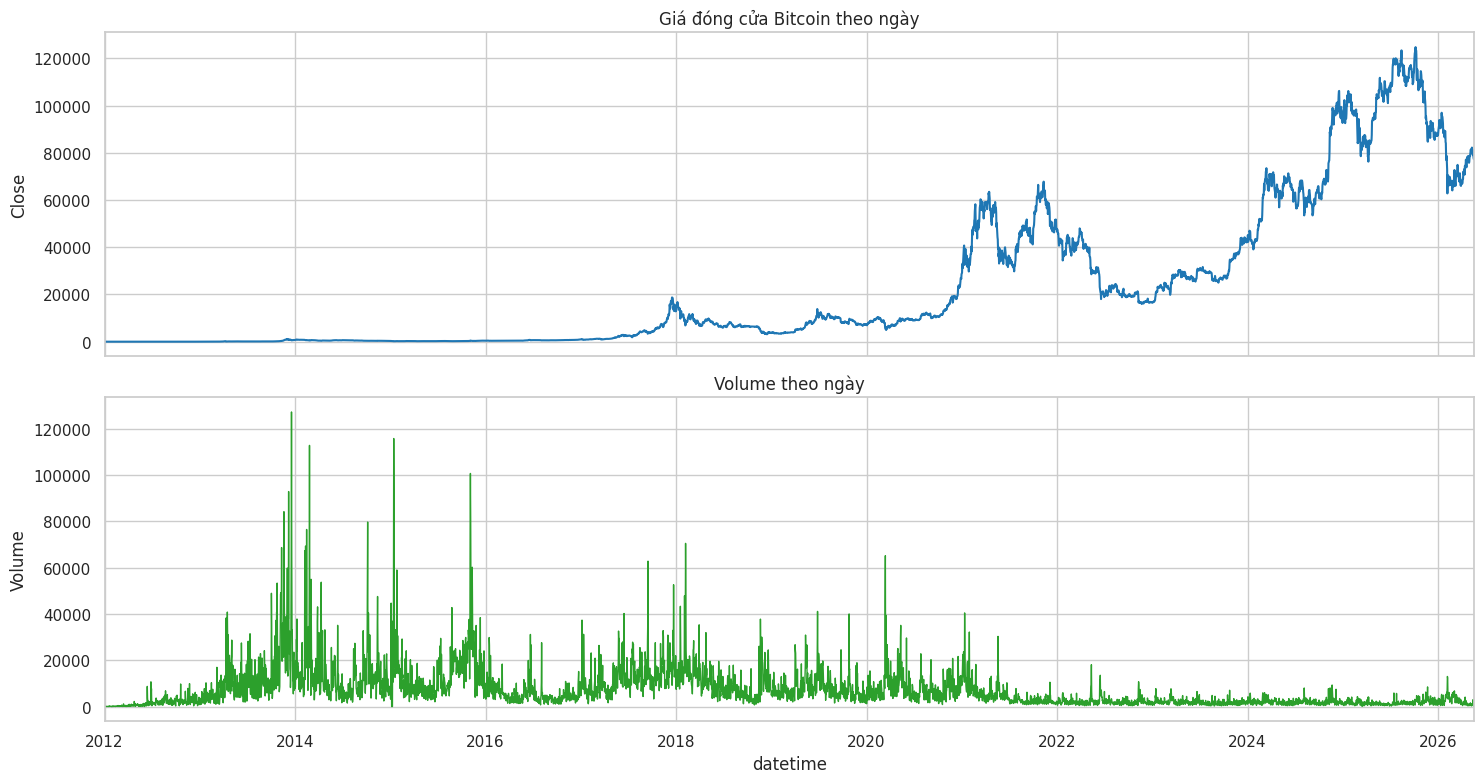

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

daily["Close"].plot(ax=axes[0], color="tab:blue", linewidth=1.5)
axes[0].set_title("Giá đóng cửa Bitcoin theo ngày")
axes[0].set_ylabel("Close")

daily["Volume"].plot(ax=axes[1], color="tab:green", linewidth=1)
axes[1].set_title("Volume theo ngày")
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

Nhận xét cần kiểm tra sau khi chạy cell:

- Giá Bitcoin thường không stationarity: trung bình và phương sai thay đổi theo thời gian.
- Volume có thể có nhiều outlier, đặc biệt trong giai đoạn biến động mạnh.
- Vì giá có trend mạnh, model dự báo trực tiếp `Close` cần scale dữ liệu và split theo thời gian, không shuffle.

## 7. Feature engineering cho chuỗi thời gian

In [30]:
features = daily.copy()

features["return_1d"] = features["Close"].pct_change()
features["log_return_1d"] = np.log(features["Close"]).diff()
features["price_range"] = features["High"] - features["Low"]
features["range_pct"] = features["price_range"] / features["Close"]
features["body"] = features["Close"] - features["Open"]
features["body_pct"] = features["body"] / features["Open"]
features["typical_price"] = (features["High"] + features["Low"] + features["Close"]) / 3

for window in [7, 14, 30]:
    features[f"ma_{window}"] = features["Close"].rolling(window).mean()
    features[f"std_{window}"] = features["Close"].rolling(window).std()
    features[f"volume_ma_{window}"] = features["Volume"].rolling(window).mean()

features["target_next_close"] = features["Close"].shift(-1)
features["target_next_return"] = features["Close"].shift(-1) / features["Close"] - 1

display(features.head(35))

,Open,High,Low,Close,Volume,return_1d,log_return_1d,price_range,range_pct,body,body_pct,typical_price,ma_7,std_7,volume_ma_7,ma_14,std_14,volume_ma_14,ma_30,std_30,volume_ma_30,target_next_close,target_next_return
datetime,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:00:00+00:00,4.580000,4.840000,4.580000,4.840000,10.000000,NaN,NaN,0.260000,0.053719,0.260000,0.056769,4.753334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,0.033058
2012-01-02 00:00:00+00:00,4.840000,5.000000,4.840000,5.000000,10.100000,0.033058,0.032523,0.160000,0.032000,0.160000,0.033058,4.946667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.290000,0.058000
2012-01-03 00:00:00+00:00,5.000000,5.320000,5.000000,5.290000,107.085281,0.058000,0.056380,0.320000,0.060492,0.290000,0.058000,5.203333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.570000,0.052930
2012-01-04 00:00:00+00:00,5.290000,5.570000,4.930000,5.570000,107.233261,0.052930,0.051577,0.640000,0.114901,0.280000,0.052930,5.356667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.420000,0.152603
2012-01-05 00:00:00+00:00,5.570000,6.460000,5.570000,6.420000,70.328743,0.152603,0.142023,0.890000,0.138629,0.850000,0.152603,6.150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.400000,-0.003115
2012-01-06 00:00:00+00:00,6.420000,6.900000,6.400000,6.400000,55.855835,-0.003115,-0.003120,0.500000,0.078125,-0.020000,-0.003115,6.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.800000,0.062500
2012-01-07 00:00:00+00:00,6.400000,6.800000,6.000000,6.800000,2.795858,0.062500,0.060625,0.800000,0.117647,0.400000,0.062500,6.533333,5.760000,0.775435,51.914140,NaN,NaN,NaN,NaN,NaN,NaN,6.900000,0.014706
2012-01-08 00:00:00+00:00,6.800000,6.900000,6.800000,6.900000,4.000000,0.014706,0.014599,0.100000,0.014493,0.100000,0.014706,6.866667,6.054286,0.758812,51.056997,NaN,NaN,NaN,NaN,NaN,NaN,6.480000,-0.060870
2012-01-09 00:00:00+00:00,6.900000,7.000000,6.360000,6.480000,64.869324,-0.060870,-0.062801,0.640000,0.098765,-0.420000,-0.060870,6.613333,6.265714,0.607120,58.881186,NaN,NaN,NaN,NaN,NaN,NaN,7.100000,0.095679


Các feature trên có ý nghĩa:

- `return_1d`, `log_return_1d`: mức thay đổi giá, thường ổn định hơn giá tuyệt đối.
- `price_range`, `range_pct`: biên độ dao động trong ngày, biểu diễn volatility.
- `body`, `body_pct`: hướng và độ mạnh của nến ngày.
- `ma_*`: xu hướng ngắn/trung hạn.
- `std_*`: độ biến động rolling.
- `volume_ma_*`: thanh khoản trung bình.
- `target_next_close`: giá đóng cửa ngày kế tiếp, dùng cho bài toán dự báo giá.

Khi train model, chỉ dùng feature tại thời điểm `t` hoặc quá khứ để dự báo `t+1`. Không được dùng dữ liệu tương lai trong input.

### Xuất dữ liệu đã làm sạch và thêm feature ra CSV

Sau khi resample theo ngày, xử lý missing do rolling window/target và thêm feature, ta xuất ra `bitcoin_features_daily.csv`. File này sẽ được dùng trực tiếp cho `train.py` và `test.py`.

In [ ]:
clean_feature_df = features.dropna().copy()
clean_feature_df.index.name = "datetime"

output_csv_candidates = [
    Path("bitcoin_features_daily.csv"),
    Path("assginment_week_11/RNN/bitcoin_features_daily.csv"),
]
output_csv_path = output_csv_candidates[0] if ZIP_PATH.name == "archive.zip" and ZIP_PATH.parent == Path(".") else output_csv_candidates[1]
output_csv_path.parent.mkdir(parents=True, exist_ok=True)

clean_feature_df.to_csv(output_csv_path)

print("Saved:", output_csv_path)
print("Shape:", clean_feature_df.shape)
display(clean_feature_df.head())
display(clean_feature_df.tail())

## 8. Phân phối return và volume

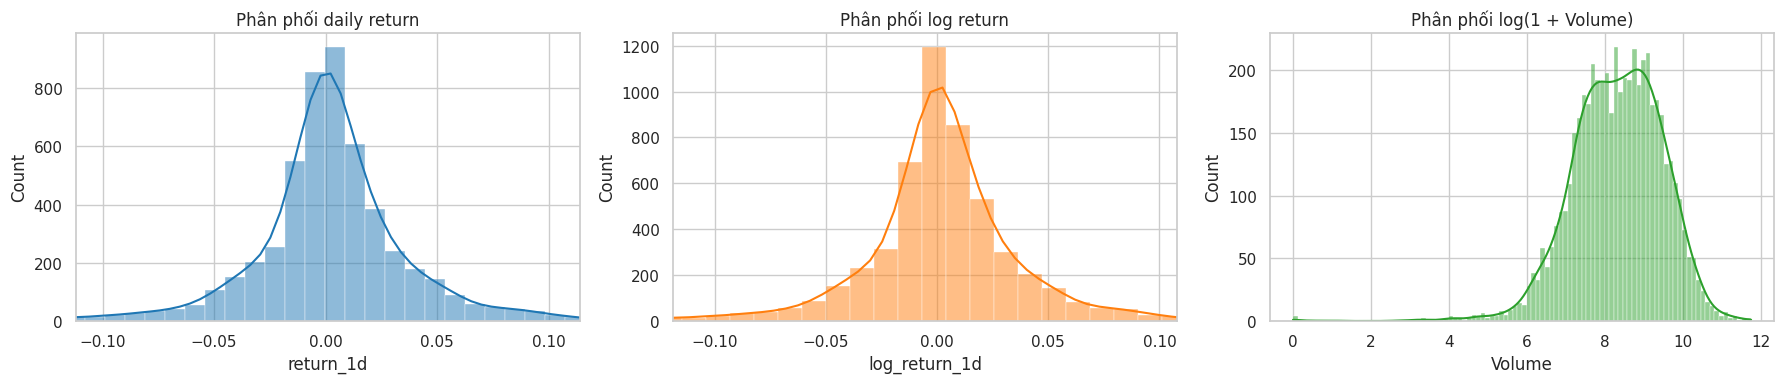

In [31]:
plot_df = features.dropna().copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(plot_df["return_1d"], bins=100, kde=True, ax=axes[0], color="tab:blue")
axes[0].set_title("Phân phối daily return")
axes[0].set_xlim(plot_df["return_1d"].quantile(0.01), plot_df["return_1d"].quantile(0.99))

sns.histplot(plot_df["log_return_1d"], bins=100, kde=True, ax=axes[1], color="tab:orange")
axes[1].set_title("Phân phối log return")
axes[1].set_xlim(plot_df["log_return_1d"].quantile(0.01), plot_df["log_return_1d"].quantile(0.99))

sns.histplot(np.log1p(plot_df["Volume"]), bins=100, kde=True, ax=axes[2], color="tab:green")
axes[2].set_title("Phân phối log(1 + Volume)")

plt.tight_layout()
plt.show()

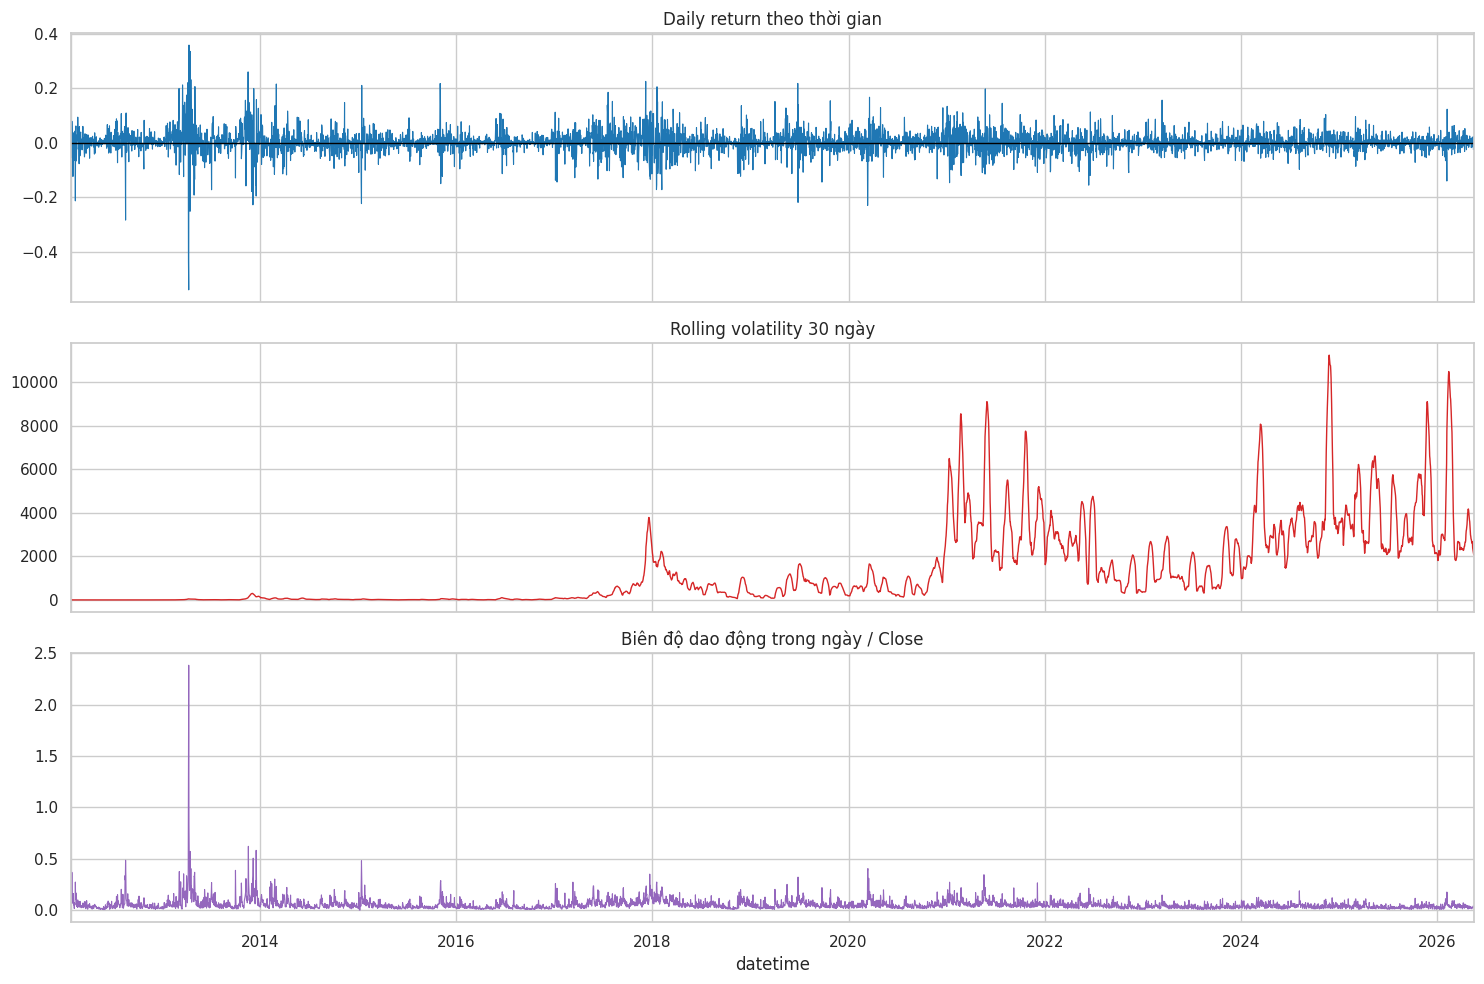

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

plot_df["return_1d"].plot(ax=axes[0], color="tab:blue", linewidth=0.8)
axes[0].set_title("Daily return theo thời gian")
axes[0].axhline(0, color="black", linewidth=1)

plot_df["std_30"].plot(ax=axes[1], color="tab:red", linewidth=1)
axes[1].set_title("Rolling volatility 30 ngày")

plot_df["range_pct"].plot(ax=axes[2], color="tab:purple", linewidth=0.8)
axes[2].set_title("Biên độ dao động trong ngày / Close")

plt.tight_layout()
plt.show()

## 9. Tương quan giữa các feature

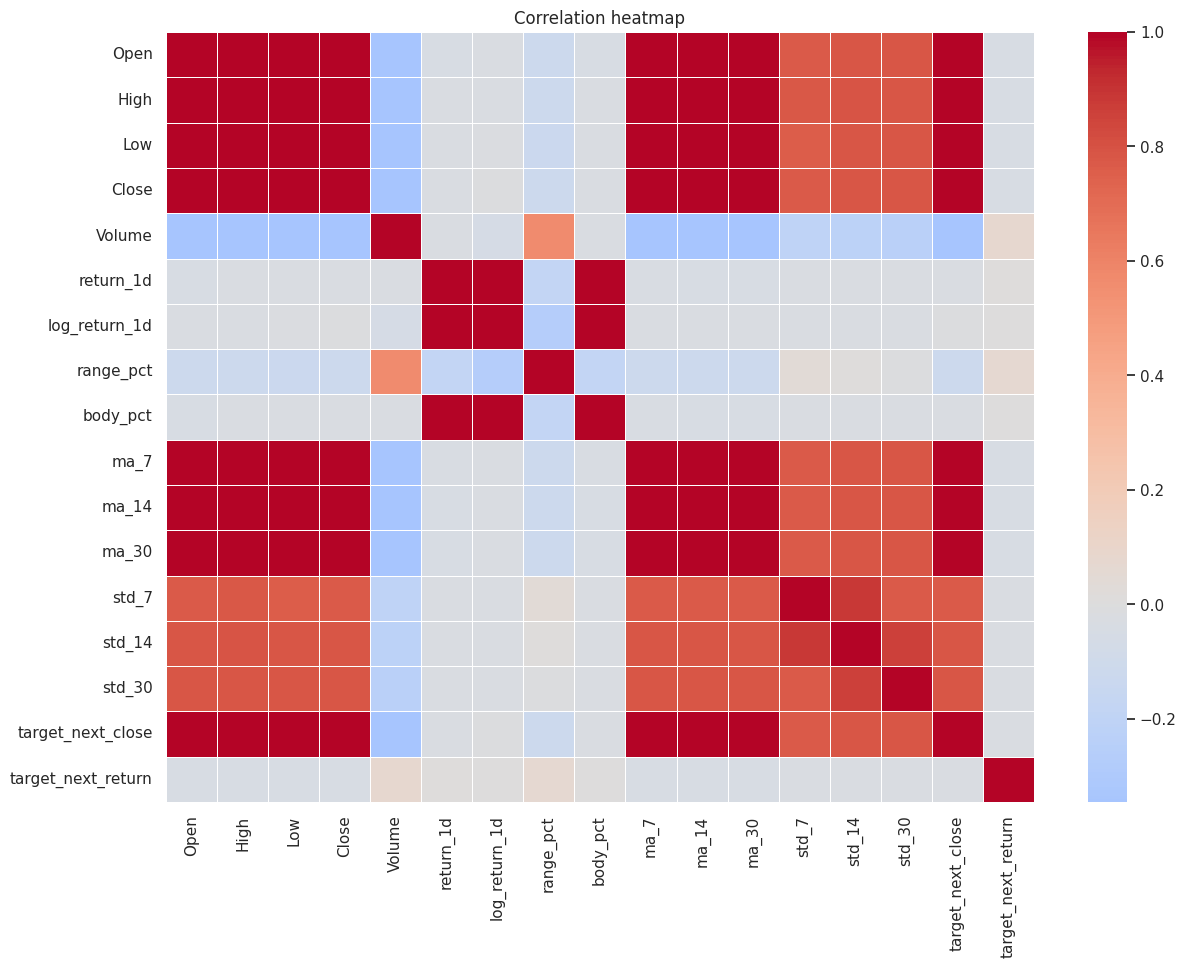

,target_next_close,target_next_return
target_next_close,1.000000,-0.020283
Close,0.999455,-0.037441
High,0.999242,-0.036800
Low,0.999200,-0.036909
Open,0.998963,-0.036574
ma_7,0.998555,-0.036999
ma_14,0.997356,-0.037206
ma_30,0.994414,-0.037680
std_14,0.785934,-0.021081
std_30,0.785012,-0.024910


In [33]:
corr_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "return_1d", "log_return_1d", "range_pct", "body_pct",
    "ma_7", "ma_14", "ma_30", "std_7", "std_14", "std_30",
    "target_next_close", "target_next_return",
]

corr = plot_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation heatmap")
plt.show()

display(corr[["target_next_close", "target_next_return"]].sort_values("target_next_close", ascending=False))

Lưu ý khi đọc correlation:

- Các biến giá như `Open`, `High`, `Low`, `Close`, `ma_*` thường tương quan rất cao với nhau vì đều mang trend giá.
- Correlation cao với `target_next_close` không đồng nghĩa model dự báo tốt, vì chuỗi giá có tính tự tương quan mạnh.
- `target_next_return` thường khó dự báo hơn `target_next_close` nhưng phản ánh bài toán tài chính thực tế hơn.

## 10. Phân tích trực quan chuyên sâu hơn

Các biểu đồ dưới đây tập trung vào đặc điểm chuỗi thời gian quan trọng cho RNN: xu hướng, biến động, drawdown, mùa vụ, tự tương quan và quan hệ giữa volume với volatility.

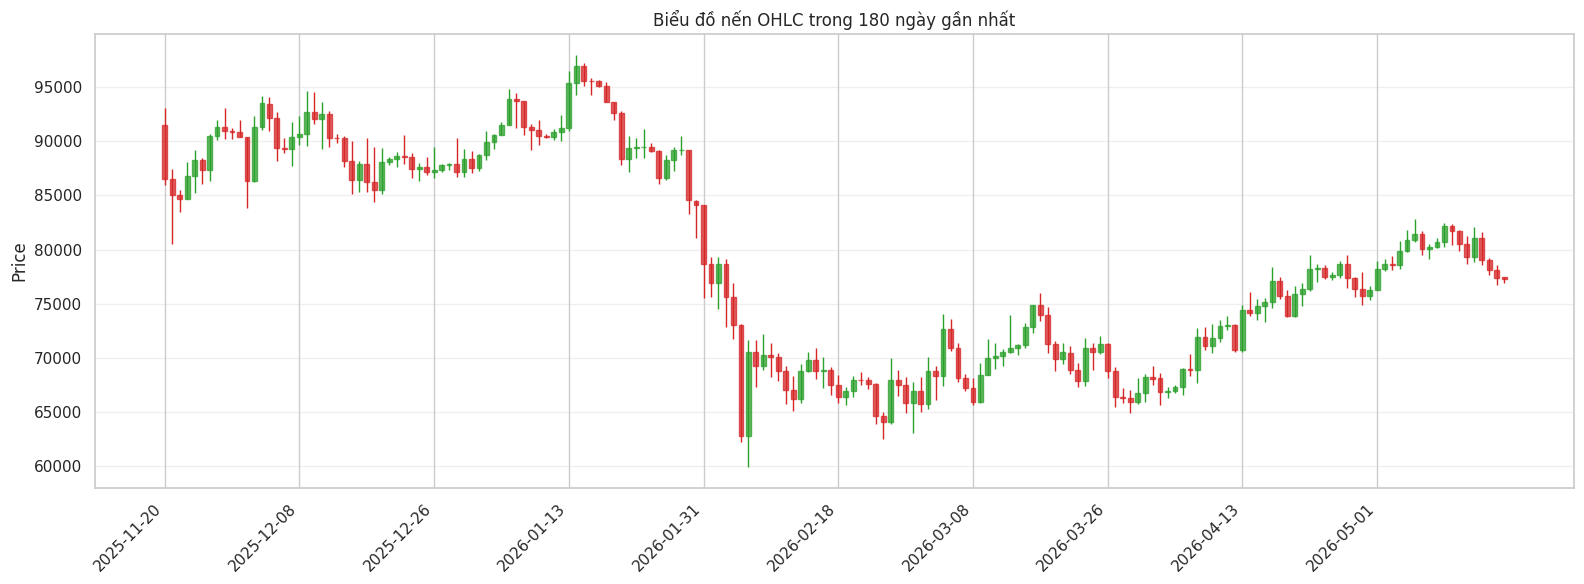

In [34]:
recent_days = 180
candle_df = daily.tail(recent_days).copy()
x = np.arange(len(candle_df))

fig, ax = plt.subplots(figsize=(16, 6))

up_color = "tab:green"
down_color = "tab:red"
body_width = 0.65

for i, (_, row) in enumerate(candle_df.iterrows()):
    color = up_color if row["Close"] >= row["Open"] else down_color
    ax.vlines(i, row["Low"], row["High"], color=color, linewidth=1)
    body_low = min(row["Open"], row["Close"])
    body_height = abs(row["Close"] - row["Open"])
    if body_height == 0:
        body_height = candle_df["Close"].median() * 0.0002
    ax.add_patch(plt.Rectangle((i - body_width / 2, body_low), body_width, body_height, color=color, alpha=0.75))

tick_step = max(1, len(candle_df) // 10)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(candle_df.index.strftime("%Y-%m-%d")[::tick_step], rotation=45, ha="right")
ax.set_title(f"Biểu đồ nến OHLC trong {recent_days} ngày gần nhất")
ax.set_ylabel("Price")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Phân tích biểu đồ nến:** Mỗi nến cho thấy quan hệ giữa `Open`, `High`, `Low`, `Close` trong một ngày. Thân nến xanh thể hiện ngày tăng, thân nến đỏ thể hiện ngày giảm; bóng nến dài thể hiện trong ngày có dao động mạnh. Với bài toán RNN, những cụm nến có thân lớn hoặc bóng dài là dấu hiệu volatility tăng, nên các feature như `range_pct`, `body_pct`, `std_7`, `std_30` có thể giúp model nhận biết giai đoạn thị trường biến động mạnh.

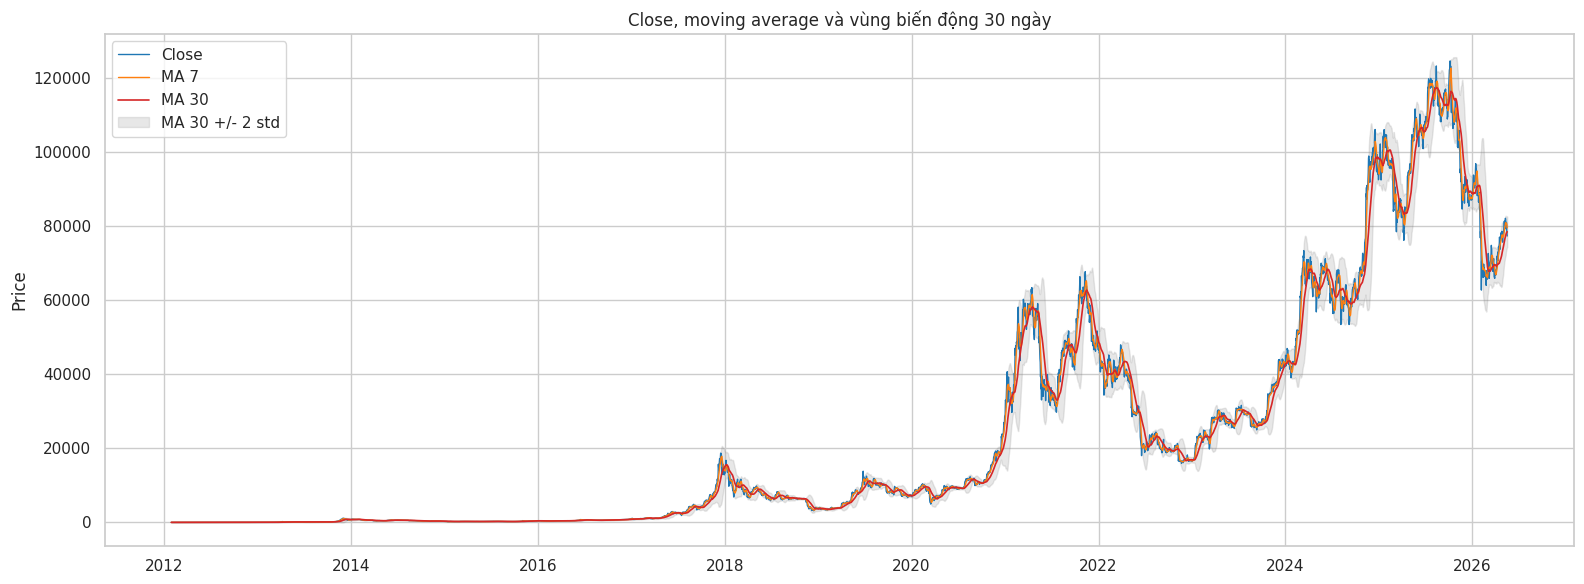

In [35]:
band_df = features.dropna().copy()
band_df["upper_band_30"] = band_df["ma_30"] + 2 * band_df["std_30"]
band_df["lower_band_30"] = band_df["ma_30"] - 2 * band_df["std_30"]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(band_df.index, band_df["Close"], label="Close", color="tab:blue", linewidth=1)
ax.plot(band_df.index, band_df["ma_7"], label="MA 7", color="tab:orange", linewidth=1)
ax.plot(band_df.index, band_df["ma_30"], label="MA 30", color="tab:red", linewidth=1.2)
ax.fill_between(
    band_df.index,
    band_df["lower_band_30"].to_numpy(),
    band_df["upper_band_30"].to_numpy(),
    color="tab:gray",
    alpha=0.18,
    label="MA 30 +/- 2 std",
)
ax.set_title("Close, moving average và vùng biến động 30 ngày")
ax.set_ylabel("Price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Phân tích MA và volatility band:** Đường `MA 7` phản ứng nhanh với biến động ngắn hạn, còn `MA 30` mượt hơn và thể hiện xu hướng trung hạn. Vùng xám càng rộng thì volatility càng cao; khi giá đi xa khỏi `MA 30`, thị trường đang lệch mạnh so với xu hướng gần đây. Điều này gợi ý RNN không nên chỉ học giá tuyệt đối mà nên có thêm feature động như moving average và rolling standard deviation.

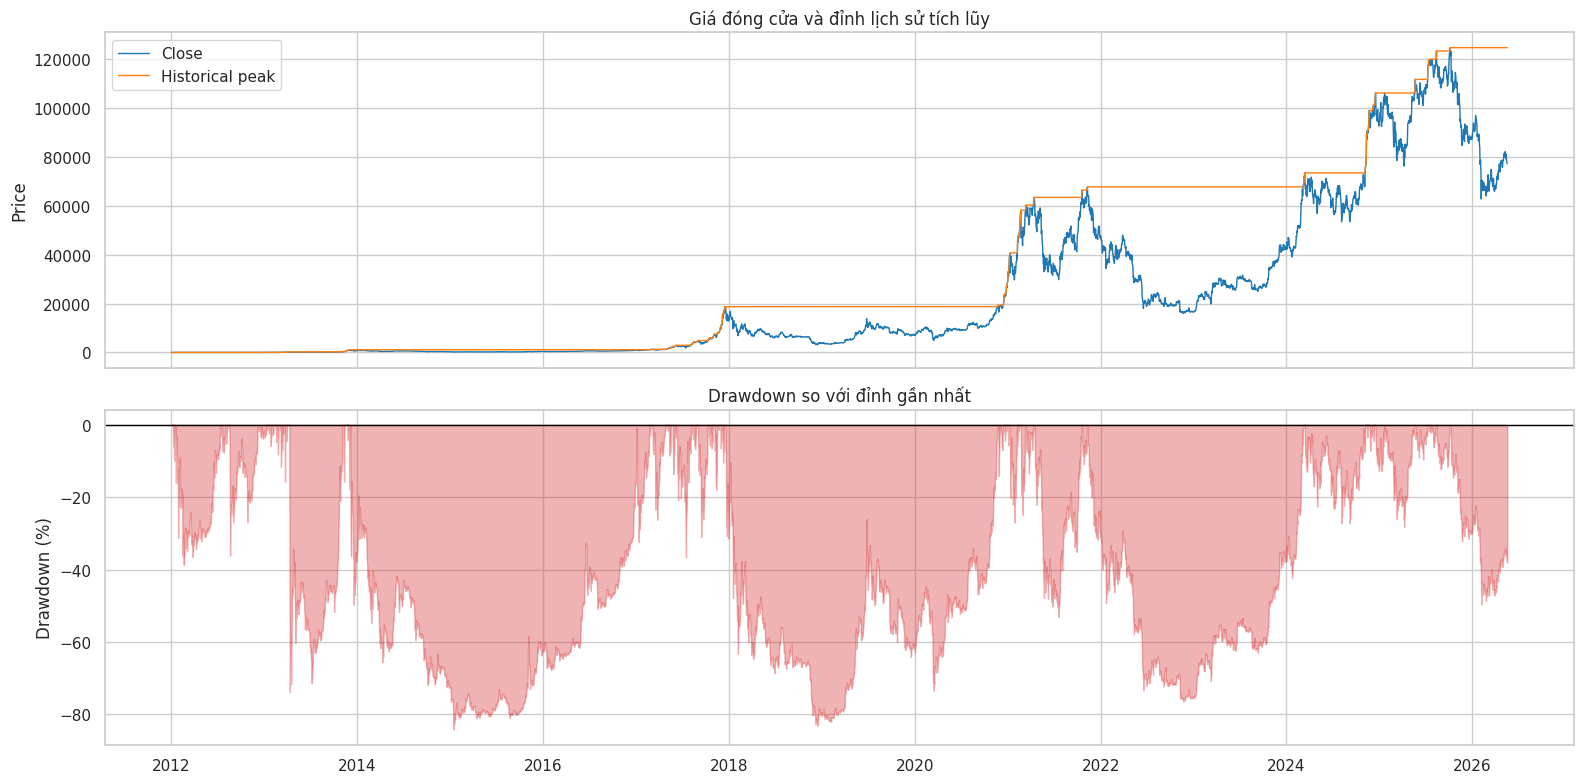

Max drawdown: -84.18% tại 2015-01-14


In [36]:
drawdown_df = daily.copy()
drawdown_df["rolling_peak"] = drawdown_df["Close"].cummax()
drawdown_df["drawdown"] = drawdown_df["Close"] / drawdown_df["rolling_peak"] - 1

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(drawdown_df.index, drawdown_df["Close"], label="Close", color="tab:blue", linewidth=1)
axes[0].plot(drawdown_df.index, drawdown_df["rolling_peak"], label="Historical peak", color="tab:orange", linewidth=1)
axes[0].set_title("Giá đóng cửa và đỉnh lịch sử tích lũy")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

axes[1].fill_between(drawdown_df.index, drawdown_df["drawdown"].to_numpy() * 100, 0, color="tab:red", alpha=0.35)
axes[1].set_title("Drawdown so với đỉnh gần nhất")
axes[1].set_ylabel("Drawdown (%)")
axes[1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

max_drawdown = drawdown_df["drawdown"].min() * 100
max_drawdown_date = drawdown_df["drawdown"].idxmin()
print(f"Max drawdown: {max_drawdown:.2f}% tại {max_drawdown_date.date()}")

**Phân tích drawdown:** Drawdown đo mức giảm từ đỉnh lịch sử gần nhất. Đây là góc nhìn quan trọng vì Bitcoin thường có chu kỳ tăng rất mạnh rồi giảm sâu. Những giai đoạn drawdown lớn cho thấy phân phối dữ liệu train không ổn định: cùng một mức giá hoặc volume có thể mang ý nghĩa khác nhau tùy regime thị trường. Khi xây RNN nên đánh giá riêng các đoạn test thuộc bull market, bear market và sideway để tránh kết luận model tốt chỉ vì dự báo được một giai đoạn dễ.

/tmp/ipykernel_89998/3312528567.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = daily["Close"].resample("M").last().dropna()


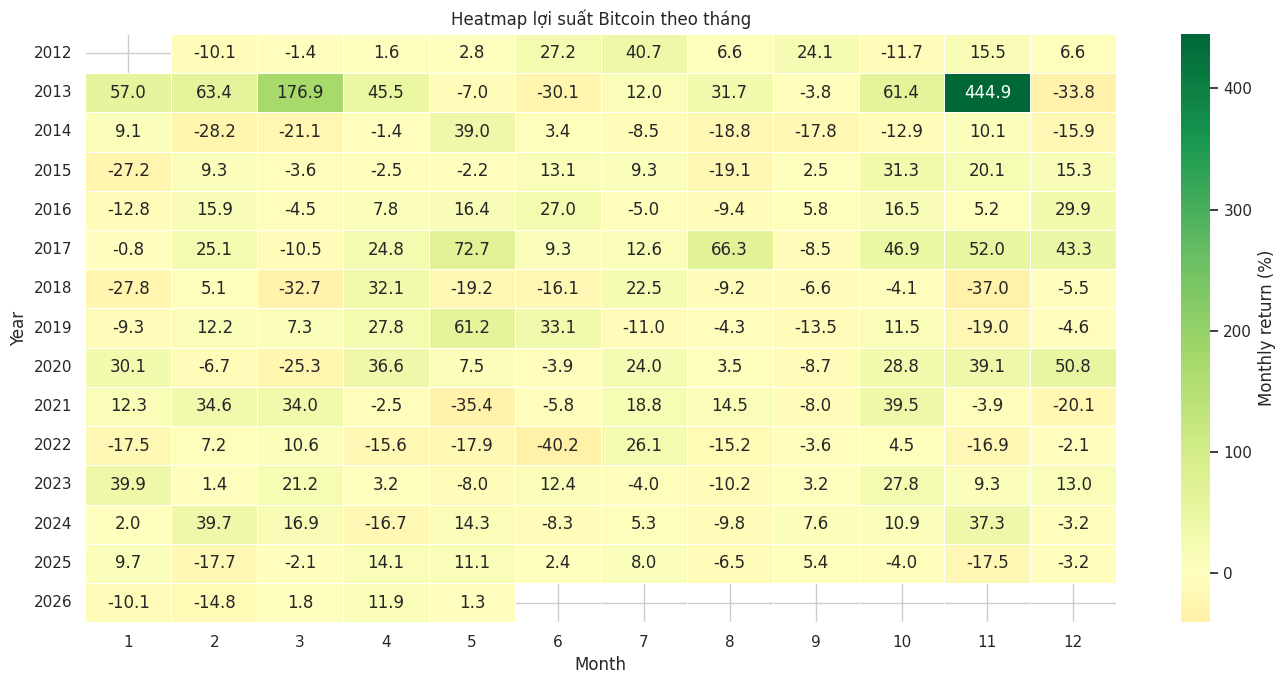

In [37]:
monthly_close = daily["Close"].resample("M").last().dropna()
monthly_return = monthly_close.pct_change().dropna() * 100

monthly_table = monthly_return.to_frame("monthly_return")
monthly_table["year"] = monthly_table.index.year
monthly_table["month"] = monthly_table.index.month
monthly_pivot = monthly_table.pivot(index="year", columns="month", values="monthly_return")

plt.figure(figsize=(14, 7))
sns.heatmap(monthly_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f", linewidths=0.5, cbar_kws={"label": "Monthly return (%)"})
plt.title("Heatmap lợi suất Bitcoin theo tháng")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

**Phân tích heatmap lợi suất tháng:** Màu xanh là tháng tăng, màu đỏ là tháng giảm. Heatmap giúp nhìn nhanh các cụm thời gian tăng/giảm mạnh và kiểm tra yếu tố mùa vụ. Nếu nhiều tháng liên tiếp cùng màu, chuỗi có momentum theo regime; nếu màu đảo liên tục, tín hiệu ngắn hạn nhiễu hơn. Với RNN, biểu đồ này nhắc rằng split train/test phải theo thời gian vì phân phối giữa các năm có thể rất khác nhau.

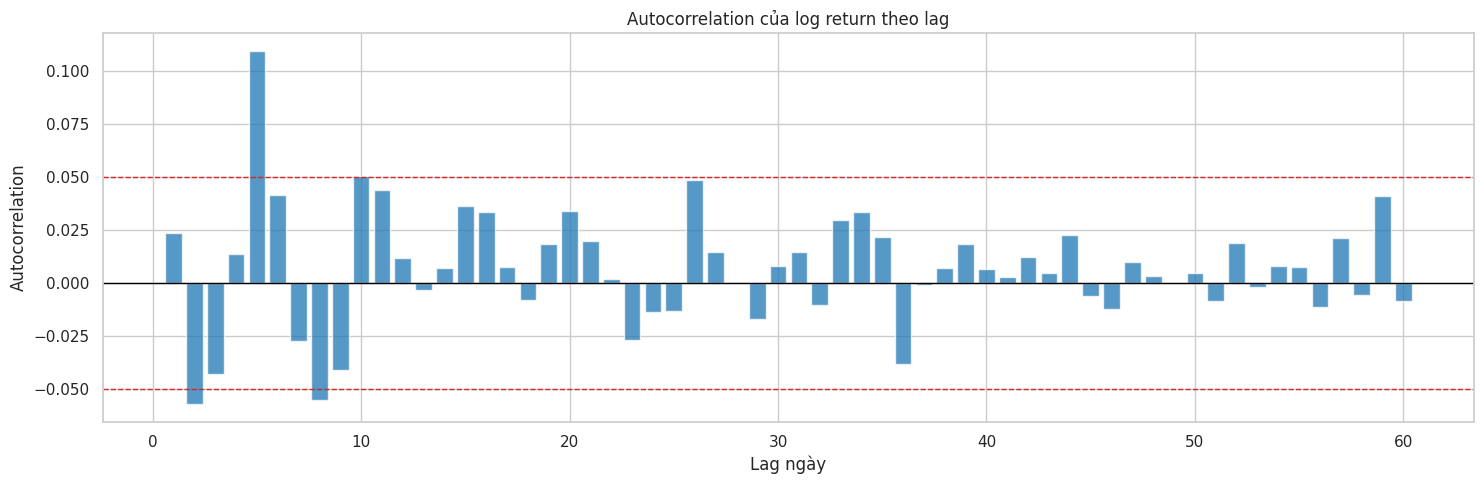

,lag,acf
4,5,0.109519
1,2,-0.057360
7,8,-0.055228
9,10,0.050597
25,26,0.048768
10,11,0.044065
2,3,-0.043276
8,9,-0.041313
5,6,0.041250
58,59,0.041090


In [38]:
acf_series = plot_df["log_return_1d"].dropna()
max_lag = 60
acf_values = [acf_series.autocorr(lag=lag) for lag in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(1, max_lag + 1), acf_values, color="tab:blue", alpha=0.75)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(0.05, color="tab:red", linestyle="--", linewidth=1)
ax.axhline(-0.05, color="tab:red", linestyle="--", linewidth=1)
ax.set_title("Autocorrelation của log return theo lag")
ax.set_xlabel("Lag ngày")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

acf_summary = pd.DataFrame({"lag": range(1, max_lag + 1), "acf": acf_values})
display(acf_summary.reindex(acf_summary["acf"].abs().sort_values(ascending=False).index).head(10))

**Phân tích autocorrelation:** Nếu autocorrelation của `log_return_1d` gần 0 ở hầu hết lag, return ngày kế tiếp khó dự báo bằng quan hệ tuyến tính đơn giản. Nếu một vài lag nổi bật, chúng có thể gợi ý độ dài cửa sổ input cho RNN. Tuy nhiên autocorrelation thấp không có nghĩa RNN chắc chắn thất bại, vì RNN có thể học quan hệ phi tuyến giữa nhiều feature; nó chỉ cho thấy bài toán dự báo return là khó hơn dự báo giá `Close` tuyệt đối.

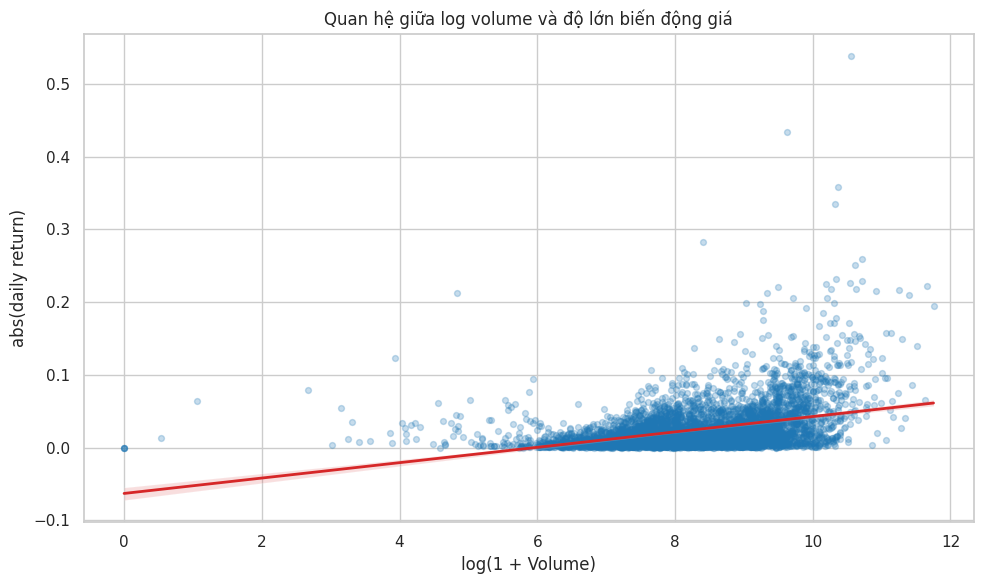

,log_volume,abs_return,range_pct,std_7
log_volume,1.000000,0.390126,0.414695,-0.209713
abs_return,0.390126,1.000000,0.769850,0.061520
range_pct,0.414695,0.769850,1.000000,0.035563
std_7,-0.209713,0.061520,0.035563,1.000000


In [39]:
scatter_df = plot_df.copy()
scatter_df["abs_return"] = scatter_df["return_1d"].abs()
scatter_df["log_volume"] = np.log1p(scatter_df["Volume"])

plt.figure(figsize=(10, 6))
sns.regplot(
    data=scatter_df,
    x="log_volume",
    y="abs_return",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "tab:red", "linewidth": 2},
)
plt.title("Quan hệ giữa log volume và độ lớn biến động giá")
plt.xlabel("log(1 + Volume)")
plt.ylabel("abs(daily return)")
plt.tight_layout()
plt.show()

corr_volume_volatility = scatter_df[["log_volume", "abs_return", "range_pct", "std_7"]].corr()
display(corr_volume_volatility)

**Phân tích volume và volatility:** Scatter plot kiểm tra trực quan liệu ngày có volume lớn thường đi kèm biến động giá lớn hay không. Nếu đường hồi quy dốc lên và correlation dương, `Volume` và `volume_ma_*` là feature đáng giữ lại cho RNN. Nếu điểm phân tán rộng, volume vẫn có ích nhưng không đủ để dự báo một mình; nên kết hợp với range, rolling std và lịch sử giá.

## Câu hỏi 1: Hệ số trong RNN là gì?

Trong RNN, “hệ số” chính là các tham số học được của mạng, gồm các ma trận trọng số và bias. Ở RNN cơ bản, tại thời điểm `t`:

$$h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$

$$y_t = W_{hy}h_t + b_y$$

Ý nghĩa từng hệ số:

- `W_xh`: trọng số biến đổi input hiện tại `x_t` vào hidden state.
- `W_hh`: trọng số hồi quy, biến đổi hidden state trước đó `h_{t-1}` sang hidden state hiện tại. Đây là phần giúp RNN nhớ thông tin quá khứ.
- `b_h`: bias của hidden state.
- `W_hy`: trọng số biến hidden state thành output.
- `b_y`: bias của output.

Điểm quan trọng: các hệ số này được chia sẻ qua mọi timestep. Nghĩa là cùng một bộ trọng số được dùng cho ngày 1, ngày 2, ..., ngày `t`. Nhờ vậy RNN học được quy luật theo thời gian mà không cần một bộ tham số riêng cho từng ngày.

Số tham số của `SimpleRNN` thường là:

$$params = units \times (input\_dim + units + 1)$$

Trong đó `+1` là bias. Với LSTM, do có 4 cổng, số tham số thường là:

$$params = 4 \times units \times (input\_dim + units + 1)$$

Với GRU, do có 3 cổng, số tham số thường xấp xỉ:

$$params = 3 \times units \times (input\_dim + units + 1)$$

Trong bài toán dự báo giá Bitcoin, các hệ số này không nên hiểu như hệ số hồi quy tuyến tính cố định. Chúng là trọng số phi tuyến, phối hợp với activation function và hidden state để học quan hệ động giữa giá, volume, volatility và lịch sử trước đó.

## Câu hỏi 2: Bidirectional RNN là gì?

Bidirectional RNN là kiến trúc chạy hai RNN song song trên cùng một sequence:

- RNN xuôi đọc chuỗi từ quá khứ đến hiện tại: `x_1 -> x_2 -> ... -> x_t`.
- RNN ngược đọc chuỗi từ hiện tại về quá khứ trong phạm vi sequence: `x_t -> ... -> x_2 -> x_1`.
- Output thường là concat hoặc cộng hai hidden state xuôi/ngược.

Công thức ý tưởng:

$$\overrightarrow{h_t} = RNN_f(x_t, \overrightarrow{h_{t-1}})$$

$$\overleftarrow{h_t} = RNN_b(x_t, \overleftarrow{h_{t+1}})$$

$$h_t = [\overrightarrow{h_t}; \overleftarrow{h_t}]$$

Ưu điểm:

- Mô hình nhìn được pattern trong sequence theo cả hai chiều.
- Thường tốt cho bài toán mà toàn bộ chuỗi input đã biết, ví dụ NLP, phân loại chuỗi, nhận dạng giọng nói, hoặc dùng một cửa sổ lịch sử cố định để dự báo điểm kế tiếp.
- Số tham số thường gần gấp đôi RNN một chiều vì có hai mạng xuôi/ngược.

Lưu ý rất quan trọng với dự báo time series:

- Không được để model nhìn dữ liệu thật sự nằm sau thời điểm cần dự báo.
- Nếu dùng cửa sổ 30 ngày `t-29 ... t` để dự báo ngày `t+1`, Bidirectional chỉ được đọc hai chiều bên trong cửa sổ 30 ngày đó. Như vậy không leak target tương lai.
- Không nên dùng Bidirectional theo kiểu đưa cả chuỗi train/test chứa các ngày sau `t+1` vào input cho một dự báo tại `t+1`, vì như vậy là leakage.

Ví dụ Keras cho bước xây model sau này:

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=False), input_shape=(sequence_length, len(feature_cols))),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
```

Với bài Bitcoin này, Bidirectional có thể thử như một biến thể so sánh với LSTM một chiều. Tuy nhiên kết quả phải được đánh giá trên validation/test theo thời gian và so với naive baseline.